In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
folder_path = "evaluate/batch1"

In [3]:
data_list = []
for file_name in os.listdir(folder_path):
    if file_name.endswith("_metrics_summary.csv"):
        model_name = "_".join(file_name.split("_")[:-2])
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path)
        df["model_name"] = model_name
        data_list.append(df)

all_data = pd.concat(data_list)

In [4]:
all_data

,Unnamed: 0,accuracy,precision,recall,f1_score,pct_greater,pct_less,pct_equal,num_nct_files,model_name
0,AND,0.113,0.107,0.113,0.107,16.77,71.95,11.28,328,Llama-3-70B-Instruct_3_shot
1,OR,0.369,0.315,0.369,0.323,11.59,51.52,36.89,328,Llama-3-70B-Instruct_3_shot
2,NOT,0.671,0.622,0.671,0.634,9.76,23.17,67.07,328,Llama-3-70B-Instruct_3_shot
3,DEPTH,0.146,0.159,0.146,0.149,15.24,70.12,14.63,328,Llama-3-70B-Instruct_3_shot
0,AND,0.150,0.169,0.150,0.155,16.54,68.50,14.96,381,Llama-3-70B-Instruct_5_shot
1,OR,0.383,0.330,0.383,0.345,17.85,43.83,38.32,381,Llama-3-70B-Instruct_5_shot
2,NOT,0.753,0.684,0.753,0.697,3.67,21.00,75.33,381,Llama-3-70B-Instruct_5_shot
3,DEPTH,0.173,0.199,0.173,0.174,11.55,71.13,17.32,381,Llama-3-70B-Instruct_5_shot
0,AND,0.254,0.211,0.254,0.188,6.78,67.83,25.39,1032,Llama-3-8B-Instruct-Gradient-1048k_10_shot
1,OR,0.304,0.416,0.304,0.342,48.06,21.51,30.43,1032,Llama-3-8B-Instruct-Gradient-1048k_10_shot


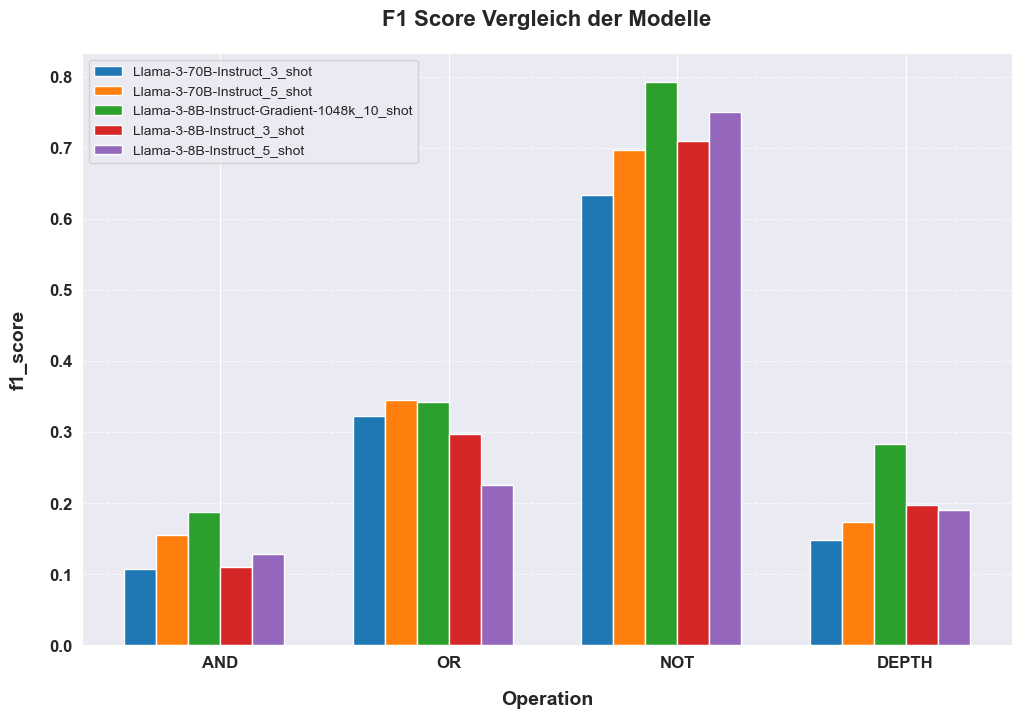

In [12]:
model_names_70B = [name for name in all_data["model_name"].unique() if "70B" in name]
model_names_8B = [name for name in all_data["model_name"].unique() if "8B" in name]

# Erstelle den Histogramm-Plot für f1_score
plt.figure(figsize=(12, 8))

operations = all_data["Unnamed: 0"].unique()
bar_width = 0.14
gap = 0 #0.05 
r = range(len(operations))

for i, model_name in enumerate(model_names_70B):
    model_data = all_data[all_data["model_name"] == model_name]
    plt.bar([x + i * bar_width for x in r], model_data["f1_score"], width=bar_width, label=model_name)

offset = len(model_names_70B) * bar_width + gap
for i, model_name in enumerate(model_names_8B):
    model_data = all_data[all_data["model_name"] == model_name]
    plt.bar([x + offset + i * bar_width for x in r], model_data["f1_score"], width=bar_width, label=model_name)

plt.xlabel("Operation", fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel("f1_score", fontsize=14, fontweight='bold', labelpad=15)
plt.title("F1 Score Vergleich der Modelle", fontsize=16, fontweight='bold', pad=20)

plt.xticks(ticks=[r + (len(model_names_70B) + len(model_names_8B)) * bar_width / 2 for r in range(len(operations))], labels=operations, fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.subplots_adjust(top=0.85)
plt.show()

In [7]:
all_data.groupby("model_name")["num_nct_files"].mean()

model_name
Llama-3-70B-Instruct_3_shot                    328.0
Llama-3-70B-Instruct_5_shot                    381.0
Llama-3-8B-Instruct-Gradient-1048k_10_shot    1032.0
Llama-3-8B-Instruct_3_shot                    1673.0
Llama-3-8B-Instruct_5_shot                     760.0
Name: num_nct_files, dtype: float64

In [8]:
def plot_metric(data, metric, title, ylabel, xlabel="Operation", figsize=(12, 8)):
    plt.figure(figsize=figsize)

    for model_name, group in data.groupby("model_name"):
        plt.plot(group[metric], label=model_name, marker='o')

    plt.xlabel(xlabel, fontsize=12, fontweight='bold', labelpad=15)
    plt.ylabel(ylabel, fontsize=12, fontweight='bold', labelpad=15)
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    operations = data["Unnamed: 0"].unique()
    plt.xticks(ticks=range(len(operations)), labels=operations, fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12)
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.subplots_adjust(top=0.85)
    plt.show()


### ML Metriken  Vergleich

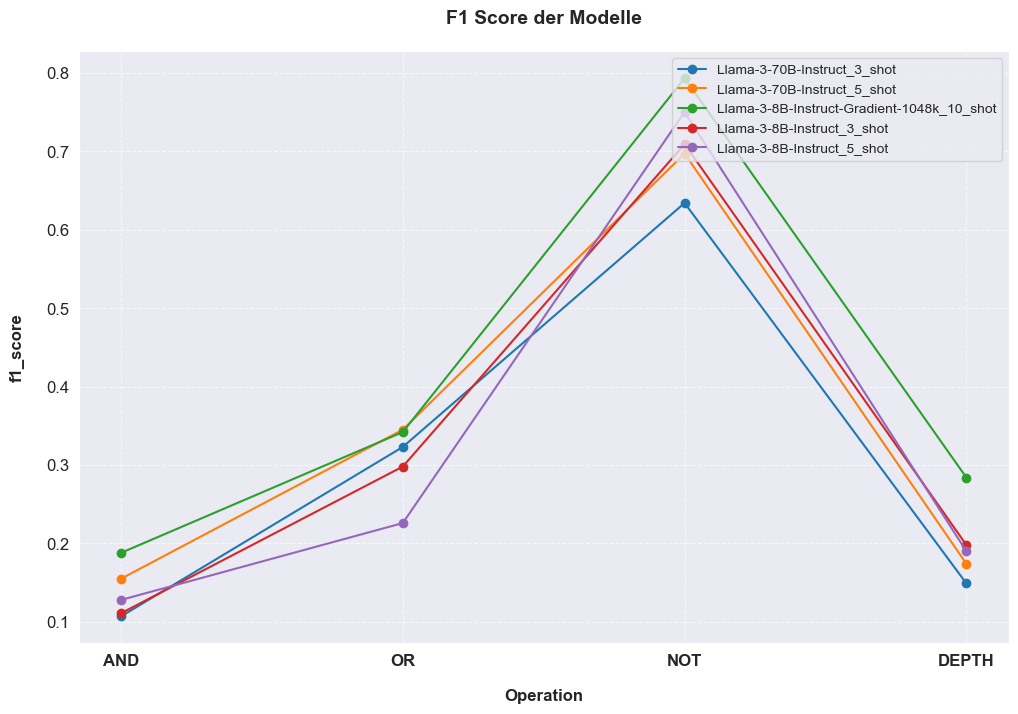

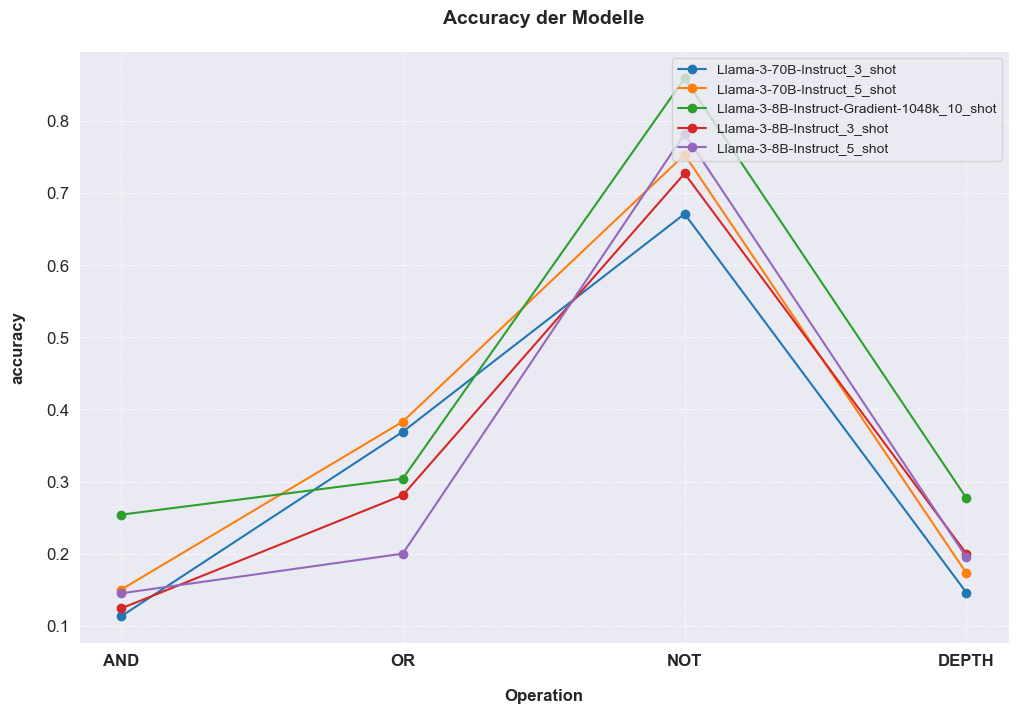

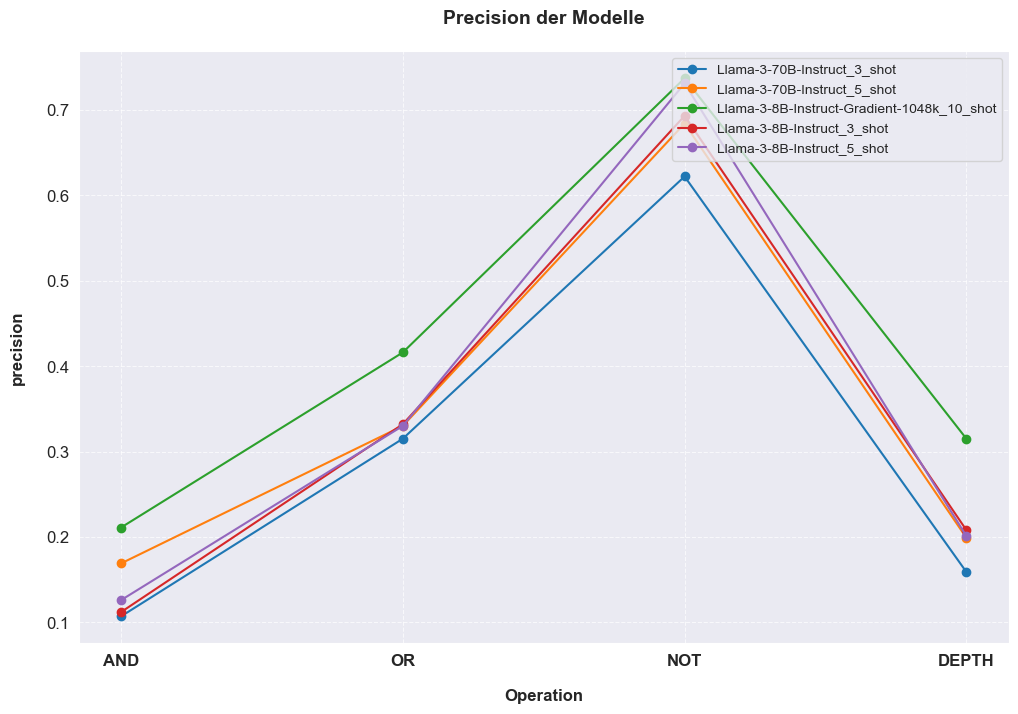

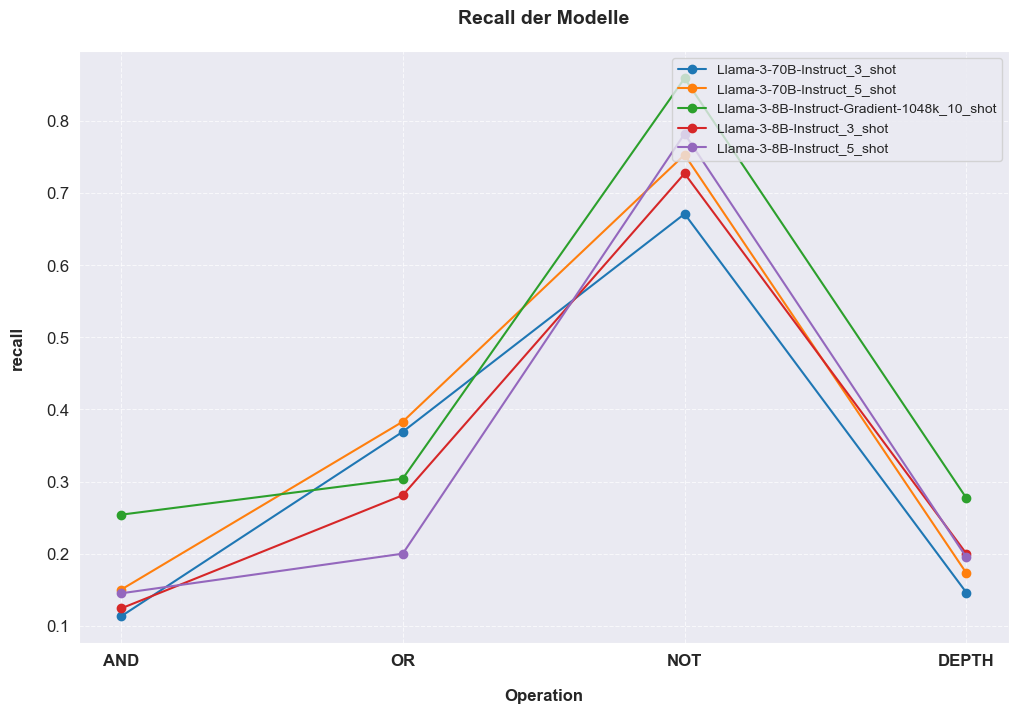

In [9]:
plot_metric(all_data, "f1_score", "F1 Score der Modelle", "f1_score")
plot_metric(all_data, "accuracy", "Accuracy der Modelle", "accuracy")
plot_metric(all_data, "precision", "Precision der Modelle", "precision")
plot_metric(all_data, "recall", "Recall der Modelle", "recall")

### PCT Vergleich

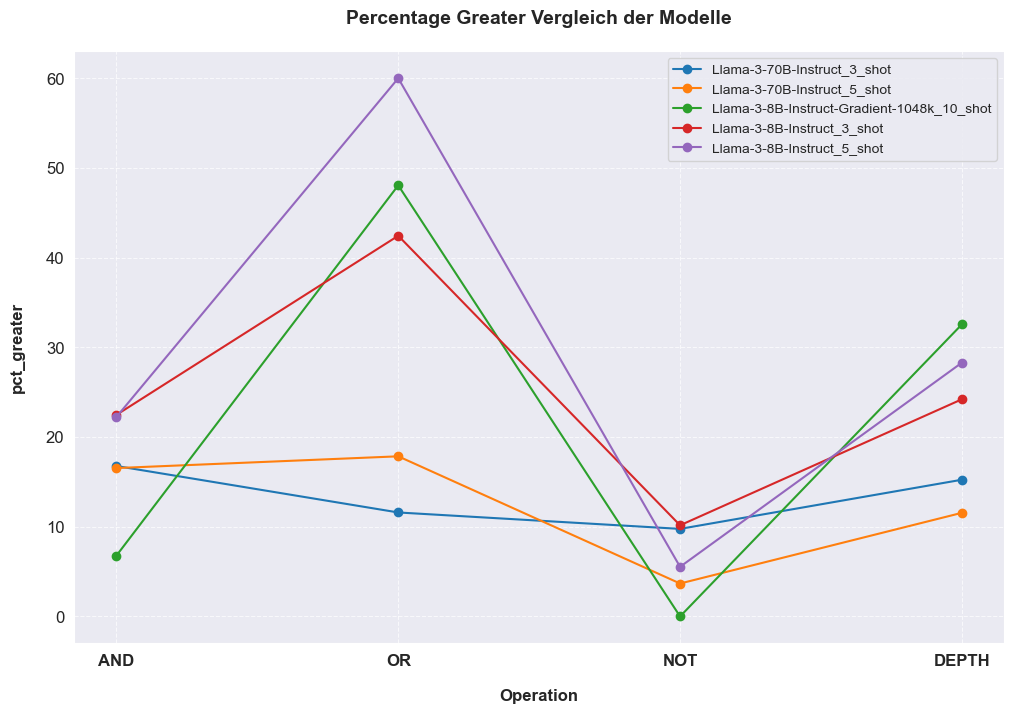

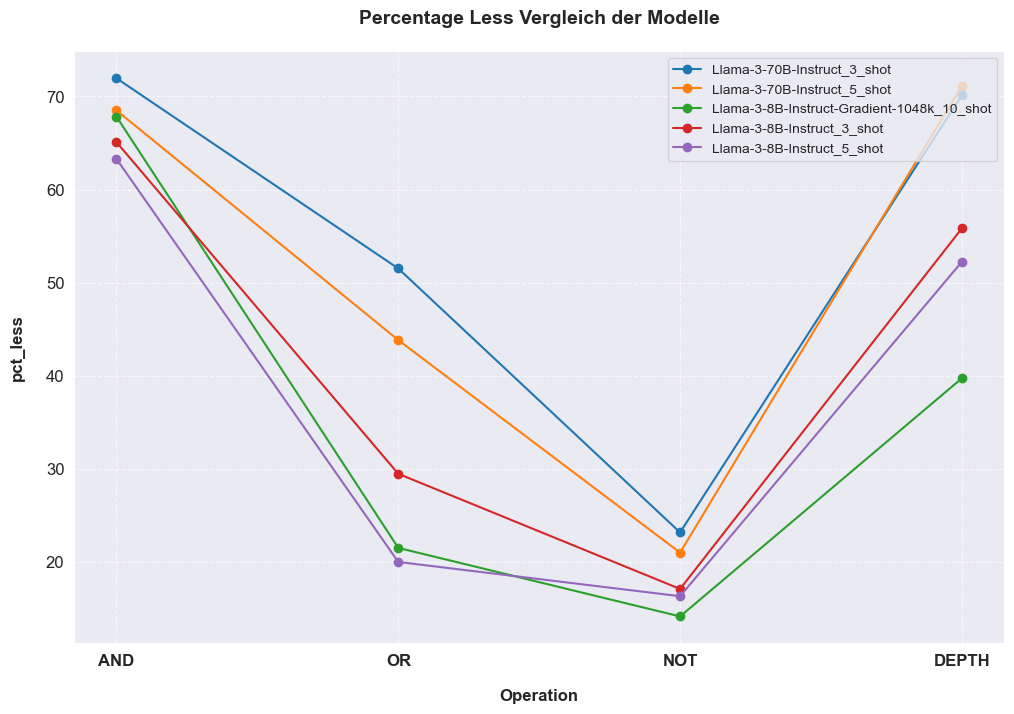

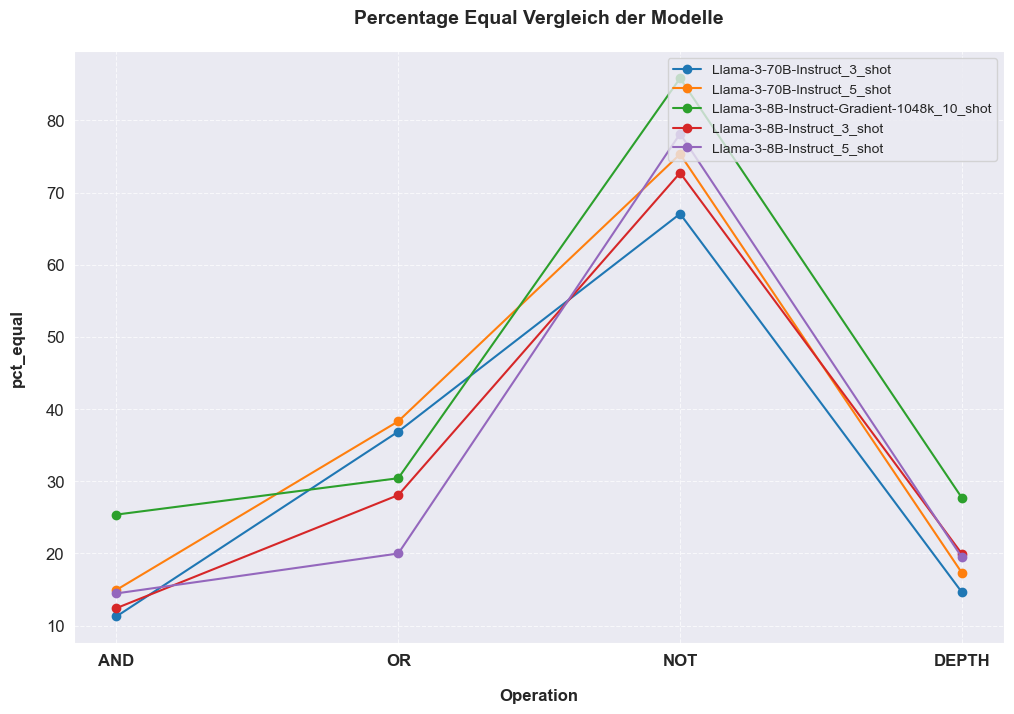

In [10]:
plot_metric(all_data, "pct_greater", "Percentage Greater Vergleich der Modelle", "pct_greater")
plot_metric(all_data, "pct_less", "Percentage Less Vergleich der Modelle", "pct_less")
plot_metric(all_data, "pct_equal", "Percentage Equal Vergleich der Modelle", "pct_equal")